<a href="https://colab.research.google.com/github/Srideep-Kundu/MLProjects/blob/main/DriverBehaviorPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas
import json

with open('/content/traffic.json', 'r') as json_data :
  data = json.load(json_data)

df = pandas.DataFrame(data['records']).head(10000)
df.head()

,trip_id,driver_id,route,state,distance_km,duration_minutes,avg_speed_kmh,behavior_class,behavior_label,sensor_features,safety_score,grade,weather,time_of_day,traffic_density,accident_risk,timestamp
0,T000001,D23133,NH-1 Delhi-Amritsar,Gujarat,184.8,260,42.7,0,normal_driving,"[0.158, 0, 0, 0.372, -0.085, 0.456, 0.036, 0.1...",36,F,fog,night,high,0.15,1730821520
1,T000002,D29720,NH-8 Delhi-Mumbai,Uttar Pradesh,130.3,169,46.1,0,normal_driving,"[0.078, 0, 0, 0.228, -0.07, 0.298, 0.036, 0.07...",39,F,clear,peak_evening,high,0.17,1742426943
2,T000003,D08650,NH-3 Agra-Mumbai,Delhi,125.7,156,48.5,0,normal_driving,"[0.127, 0, 0, 0.374, -0.086, 0.459, 0.045, 0.1...",30,F,fog,night,high,0.14,1738703905
3,T000004,D31719,Yamuna Expressway,Rajasthan,165.0,212,46.6,2,sharp_turn,"[0.153, 0, 0, 0.4, -0.096, 0.496, 4.209, 13.80...",37,F,heavy_rain,midday,high,0.06,1745921559
4,T000005,D26385,Yamuna Expressway,Maharashtra,129.0,128,60.5,3,aggressive_acceleration,"[2.796, 0, 0, 2.959, 2.64, 0.319, 0.176, 0.028...",50,F,cloudy,night,high,0.06,1751267102


In [19]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# 1. Define the target variable 'is_risky' based on the 'safety_score' column.
# A possible threshold could be a safety score below 50.
df_selected['is_risky'] = (df_selected['safety_score'] < 50).astype(int)

# 2. Define the feature set X using the selected features from df_selected and the target variable y.
X = df_selected.drop(['safety_score', 'is_risky'], axis=1)
y = df_selected['is_risky']

# 3. Convert categorical features in X to numerical using one-hot encoding.
X = pd.get_dummies(X, columns=['weather', 'time_of_day', 'traffic_density'], drop_first=True)

# Convert X to a numpy array with a float data type
X = X.values.astype(np.float32)
y = y.values.astype(np.float32)


# 4. Split the data into training and a temporary set (for cross-validation and testing) with a ratio of 70/30.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 5. Split the temporary set into cross-validation and test sets with a ratio of 50/50.
X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Display the shapes of the resulting sets to verify the split
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_cv:", X_cv.shape)
print("Shape of y_cv:", y_cv.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7000, 16)
Shape of y_train: (7000,)
Shape of X_cv: (1500, 16)
Shape of y_cv: (1500,)
Shape of X_test: (1500, 16)
Shape of y_test: (1500,)


In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Reshape the data for CNN input (add a channel dimension)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_cv_cnn = X_cv.reshape(X_cv.shape[0], X_cv.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Define the CNN model architecture
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Train the model
# Using a small number of epochs for demonstration, more epochs might be needed for better performance
history = cnn_model.fit(X_train_cnn, y_train, epochs=20, batch_size=32, validation_data=(X_cv_cnn, y_cv))

print("CNN model trained successfully.")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5071 - loss: 1.7422 - val_accuracy: 0.5447 - val_loss: 0.6689
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5438 - loss: 0.6766 - val_accuracy: 0.7713 - val_loss: 0.6223
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6414 - loss: 0.6094 - val_accuracy: 0.8227 - val_loss: 0.4690
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7579 - loss: 0.4970 - val_accuracy: 0.8573 - val_loss: 0.4167
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7659 - loss: 0.4525 - val_accuracy: 0.8347 - val_loss: 0.4145
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7665 - loss: 0.4534 - val_accuracy: 0.8533 - val_loss: 0.3602
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7909 - loss: 0.4389 - val_accuracy: 0.8487 - val_loss: 0.3636
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7797 - loss: 0.4284 - val_accuracy: 0.8580 - val_

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np # Import numpy for metrics calculation

# Make predictions on the cross-validation set
y_pred_cv_cnn_prob = cnn_model.predict(X_cv_cnn)
y_pred_cv_cnn = (y_pred_cv_cnn_prob > 0.5).astype(int) # Convert probabilities to binary predictions

# Calculate evaluation metrics
accuracy_cv_cnn = accuracy_score(y_cv, y_pred_cv_cnn)
precision_cv_cnn = precision_score(y_cv, y_pred_cv_cnn)
recall_cv_cnn = recall_score(y_cv, y_pred_cv_cnn)
f1_cv_cnn = f1_score(y_cv, y_pred_cv_cnn)

# Print the evaluation metrics
print(f"Cross-validation Accuracy (CNN): {accuracy_cv_cnn:.4f}")
print(f"Cross-validation Precision (CNN): {precision_cv_cnn:.4f}")
print(f"Cross-validation Recall (CNN): {recall_cv_cnn:.4f}")
print(f"Cross-validation F1-score (CNN): {f1_cv_cnn:.4f}")

# Outline a plan for hyperparameter tuning if needed (based on the metrics printed)
print("\nPlan for Hyperparameter Tuning (if needed):")
print("Based on the evaluation metrics, if the performance is not satisfactory,")
print("hyperparameter tuning for the CNN will be considered.")
print("Relevant hyperparameters to tune include:")
print("- Number of filters and kernel size in Conv1D layers.")
print("- Number of neurons in Dense layers.")
print("- Dropout rate.")
print("- Learning rate of the optimizer.")
print("- Number of epochs and batch size.")
print("Techniques like Keras Tuner can be used for tuning.")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Cross-validation Accuracy (CNN): 0.8573
Cross-validation Precision (CNN): 0.8335
Cross-validation Recall (CNN): 0.9215
Cross-validation F1-score (CNN): 0.8753

Plan for Hyperparameter Tuning (if needed):
Based on the evaluation metrics, if the performance is not satisfactory,
hyperparameter tuning for the CNN will be considered.
Relevant hyperparameters to tune include:
- Number of filters and kernel size in Conv1D layers.
- Number of neurons in Dense layers.
- Dropout rate.
- Learning rate of the optimizer.
- Number of epochs and batch size.
Techniques like Keras Tuner can be used for tuning.



Assessing Overfitting/Underfitting based on Training History:


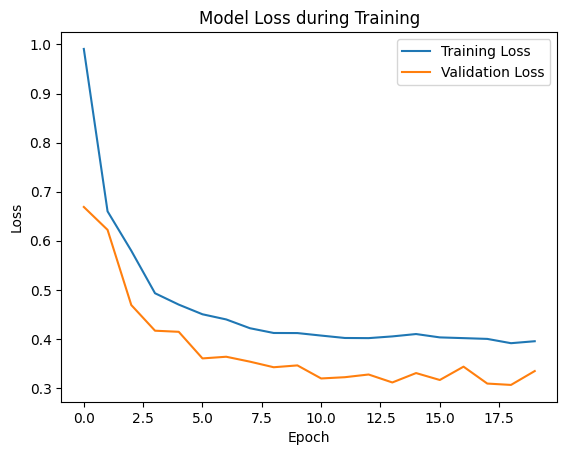

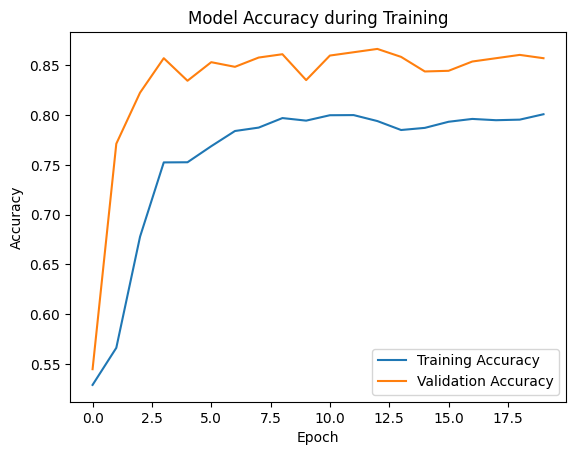


Mitigation Strategy (Based on Visual Assessment):
If plots indicate overfitting (large gap between training and validation curves), consider:
- Increasing Dropout rate.
- Adding more regularization (e.g., L1 or L2 regularization).
- Reducing the number of neurons or layers.
If plots indicate underfitting (both curves flat and low), consider:
- Increasing the number of epochs.
- Increasing model complexity (e.g., adding more layers or neurons).
- Adjusting learning rate.


In [31]:
# Assess model performance based on training and validation metrics
# If training loss is much lower than validation loss, overfitting might be occurring.
# If both training and validation losses are high, underfitting might be occurring.

print("\nAssessing Overfitting/Underfitting based on Training History:")
# Access training history from the 'history' object
# For example, plot the training and validation loss over epochs
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy during Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Based on the plots and metrics, decide on mitigation strategies
print("\nMitigation Strategy (Based on Visual Assessment):")
print("If plots indicate overfitting (large gap between training and validation curves), consider:")
print("- Increasing Dropout rate.")
print("- Adding more regularization (e.g., L1 or L2 regularization).")
print("- Reducing the number of neurons or layers.")
print("If plots indicate underfitting (both curves flat and low), consider:")
print("- Increasing the number of epochs.")
print("- Increasing model complexity (e.g., adding more layers or neurons).")
print("- Adjusting learning rate.")

# Example of implementing a mitigation strategy (e.g., adding more epochs if underfitting is suspected)
# Note: This is a conceptual example, the actual strategy depends on the plots.
# If you decide to retrain with different hyperparameters or architecture, define and train a new model.
# For demonstration, let's assume underfitting and train for more epochs (if needed based on plots)
# print("\nRetraining with more epochs (if needed based on plots):")
# cnn_model_tuned = Sequential([
#     Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
#     Flatten(),
#     Dense(64, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])
# cnn_model_tuned.compile(optimizer=Adam(learning_rate=0.001),
#                   loss='binary_crossentropy',
#                   metrics=['accuracy'])
# history_tuned = cnn_model_tuned.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_data=(X_cv_cnn, y_cv))

# After retraining (if done), re-evaluate on the cross-validation set
# print("\nRe-evaluation on Cross-validation set after retraining:")
# y_pred_cv_cnn_tuned_prob = cnn_model_tuned.predict(X_cv_cnn)
# y_pred_cv_cnn_tuned = (y_pred_cv_cnn_tuned_prob > 0.5).astype(int)
# accuracy_cv_cnn_tuned = accuracy_score(y_cv, y_pred_cv_cnn_tuned)
# precision_cv_cnn_tuned = precision_score(y_cv, y_pred_cv_cnn_tuned)
# recall_cv_cnn_tuned = recall_score(y_cv, y_pred_cv_cnn_tuned)
# f1_cv_cnn_tuned = f1_score(y_cv, y_pred_cv_cnn_tuned)
# print(f"Cross-validation Accuracy (Tuned CNN): {accuracy_cv_cnn_tuned:.4f}")
# print(f"Cross-validation Precision (Tuned CNN): {precision_cv_cnn_tuned:.4f}")
# print(f"Cross-validation Recall (Tuned CNN): {recall_cv_cnn_tuned:.4f}")
# print(f"Cross-validation F1-score (Tuned CNN): {f1_cv_cnn_tuned:.4f}")

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Use the trained cnn_model (or cnn_model_tuned if you retrained) to make predictions on the test feature set X_test_cnn.
y_pred_test_cnn_prob = cnn_model.predict(X_test_cnn)
y_pred_test_cnn = (y_pred_test_cnn_prob > 0.5).astype(int) # Convert probabilities to binary predictions


# Calculate the accuracy, precision, recall, and F1-score of the predictions using the true labels y_test.
accuracy_test_cnn = accuracy_score(y_test, y_pred_test_cnn)
precision_test_cnn = precision_score(y_test, y_pred_test_cnn)
recall_test_cnn = recall_score(y_test, y_pred_test_cnn)
f1_test_cnn = f1_score(y_test, y_pred_test_cnn)

# Print the calculated evaluation metrics for the test set.
print(f"Test Set Accuracy (CNN): {accuracy_test_cnn:.4f}")
print(f"Test Set Precision (CNN): {precision_test_cnn:.4f}")
print(f"Test Set Recall (CNN): {recall_test_cnn:.4f}")
print(f"Test Set F1-score (CNN): {f1_test_cnn:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Set Accuracy (CNN): 0.8380
Test Set Precision (CNN): 0.8053
Test Set Recall (CNN): 0.9251
Test Set F1-score (CNN): 0.8611


In [33]:
import json
import pandas as pd
import numpy as np

# Select a sample record (e.g., the first record from the original data)
sample_record = data['records'][0]

# Convert the sample record to a pandas DataFrame for easier preprocessing
sample_df = pd.DataFrame([sample_record])

# Apply the same feature extraction for sensor_features as done for the training data
sample_df['sensor_feature_1'] = sample_df['sensor_features'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 0.0)
sample_df['sensor_feature_2'] = sample_df['sensor_features'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else 0.0)

# Select the same features used for training
selected_features = [
    'distance_km',
    'duration_minutes',
    'avg_speed_kmh',
    'safety_score',
    'weather',
    'sensor_feature_1',
    'sensor_feature_2',
    'time_of_day',
    'traffic_density',
    'accident_risk'
]
sample_df_selected = sample_df[selected_features].copy()

# Apply one-hot encoding to the categorical features.
# It's important to use the same columns and categories as the training data's one-hot encoding.
# To ensure this, we can fit and transform a OneHotEncoder on the training data's categorical columns first,
# then use that fitted encoder to transform the sample data. However, a simpler approach for prediction
# with get_dummies is to reindex the columns after one-hot encoding the sample data, aligning them
# with the training data's one-hot encoded columns.

# Get the list of columns after one-hot encoding the training data
# This assumes that X_train is the one-hot encoded numpy array from the training data
# Let's re-create the one-hot encoded columns list based on the original df_selected and the one-hot encoding logic
categorical_cols = ['weather', 'time_of_day', 'traffic_density']
# Create a dummy DataFrame to get the column names after one-hot encoding
dummy_df = pd.get_dummies(df_selected[selected_features], columns=categorical_cols, drop_first=True)
one_hot_encoded_cols = dummy_df.drop('safety_score', axis=1).columns.tolist()


sample_df_encoded = pd.get_dummies(sample_df_selected, columns=categorical_cols, drop_first=True)

# Reindex the sample_df_encoded to match the columns of the training data's one-hot encoded features (excluding 'safety_score')
# Fill missing columns with 0. This is crucial if the sample data does not contain all categories present in the training data.
sample_df_aligned = sample_df_encoded.reindex(columns=one_hot_encoded_cols, fill_value=0)


# Convert to numpy array and reshape for CNN input
sample_input = sample_df_aligned.values.astype(np.float32)
sample_input_cnn = sample_input.reshape(sample_input.shape[0], sample_input.shape[1], 1)

# Use the trained CNN model to make a prediction
prediction_prob = cnn_model.predict(sample_input_cnn)
prediction = (prediction_prob > 0.5).astype(int)

# Interpret the prediction
behavior_label = "risky driving" if prediction[0][0] == 1 else "normal driving"

print(f"Sample Record: {sample_record}")
print(f"\nPredicted Driver Behavior: {behavior_label}")
print(f"Prediction Probability: {prediction_prob[0][0]:.4f}")

# Get the actual behavior label from the sample record
actual_behavior_label = sample_record.get('behavior_label', 'N/A') # Use .get to handle potential missing key

print(f"Actual Driver Behavior: {actual_behavior_label}")

# Compare prediction with actual
if (prediction[0][0] == 1 and actual_behavior_label == 'risky_driving') or \
   (prediction[0][0] == 0 and actual_behavior_label == 'normal_driving'):
    print("Prediction Matches Actual Behavior.")
else:
    print("Prediction Does Not Match Actual Behavior.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Sample Record: {'trip_id': 'T000001', 'driver_id': 'D23133', 'route': 'NH-1 Delhi-Amritsar', 'state': 'Gujarat', 'distance_km': 184.8, 'duration_minutes': 260, 'avg_speed_kmh': 42.7, 'behavior_class': 0, 'behavior_label': 'normal_driving', 'sensor_features': [0.158, 0, 0, 0.372, -0.085, 0.456, 0.036, 0.193, 0.676, 0.261, -0.19, 0.451, -0.985, 2.078, 0.671, -0.752, -1.21, 0.458, 0.009, 0.206, 0.677, 0.132, -0.104, 0.236, 0.02, 0.051, 0.486, 0.131, -0.106, 0.237, 0.026, 0.049, 0.487, 0.144, -0.094, 0.239, 103.382, 103.382], 'safety_score': 36, 'grade': 'F', 'weather': 'fog', 'time_of_day': 'night', 'traffic_density': 'high', 'accident_risk': 0.15, 'timestamp': 1730821520}

Predicted Driver Behavior: normal driving
Prediction Probability: 0.0259
Actual Driver Behavior: normal_driving
Prediction Matches Actual Behavior.
